# Visualization of bilipschitz activations

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from dlroms import * 
import os
import sys
sys.path.insert(0, '..')
from src.utils import *
from src.activations import *


### Compute activation outputs

In [5]:
# Generate ranges
x_lin = dv.tensor(np.linspace(-3,3,1001))
alphas_leaky = np.linspace(1/3,3,30)
betas_leaky = np.linspace(1/3,3,30)
thetas_smooth = np.linspace(0.1, np.pi / 4 - 0.1, 30)

# LeakyReLU_{\alpha,1}
ys_leaky_alpha = list()
for alpha in alphas_leaky:
    ys_leaky_alpha.append(LeakyReLU(alpha).act(x_lin).detach().cpu().numpy())

# LeakyReLU_{1,\beta}
ys_leaky_beta = list()
for beta in betas_leaky:
    ys_leaky_beta.append(LeakyReLU(1,beta).act(x_lin).detach().cpu().numpy())

# Hypact_{\theta}
ys_smooth = list()
for theta in thetas_smooth:
    ys_smooth.append(HypAct(theta).act(x_lin).detach().cpu().numpy())

# Postprocess
x_lin = x_lin.detach().cpu().numpy()
ys_leaky_alpha = np.array(ys_leaky_alpha)
ys_leaky_beta = np.array(ys_leaky_beta)
ys_smooth = np.array(ys_smooth)

### Visualize activation effect

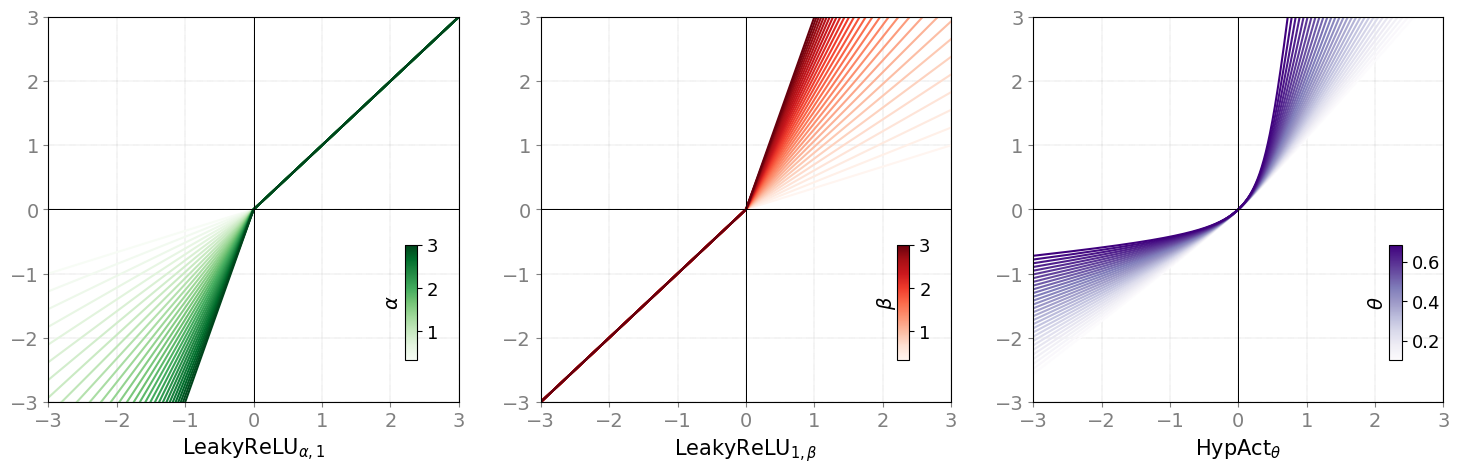

In [6]:
fig, ax = plt.subplots(1, 3, figsize = (18,5))


# LeakyReLU_{\alpha,1}
cmap = mpl.colormaps['Greens']
colors = cmap(np.linspace(0, 1, ys_leaky_alpha.shape[0]))
for i, color in enumerate(colors):
    ax[0].plot(x_lin, ys_leaky_alpha[i], color = color)
    ax[0].grid(color='grey', linestyle=':', linewidth=0.3)
    ax[0].set_xlim([-3,3])
    ax[0].set_ylim([-3,3])
    ax[0].hlines(0, xmin =-3, xmax = 3, color = 'k', linewidth = 0.5)
    ax[0].vlines(0, ymin =-3, ymax = 3, color = 'k', linewidth = 0.5)
alpha_leaky_mappable = mpl.cm.ScalarMappable(norm=None, cmap=cmap)
alpha_leaky_mappable.set_array(alphas_leaky)
cax = inset_axes(ax[0], width="3%", height="30%", loc=4, borderpad=3) 
cbar = fig.colorbar(alpha_leaky_mappable, ax=ax[0], cax=cax)
cbar.set_label('$\\alpha$', rotation=90, labelpad = -40, fontsize = 14)
ax[0].set_xlabel('$\\text{LeakyReLU}_{\\alpha,1}$', fontsize = 15)
cax.tick_params(axis='both', which='major', labelsize=13)
ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[0].tick_params(axis='both', which='minor', labelsize=14)
ax[0].tick_params(axis='x', colors='grey')
ax[0].tick_params(axis='y', colors='grey')


# LeakyReLU_{1,\beta}
cmap = mpl.colormaps['Reds']
colors = cmap(np.linspace(0, 1, ys_leaky_beta.shape[0]))
for i, color in enumerate(colors):
    ax[1].plot(x_lin, ys_leaky_beta[i], color = color)
    ax[1].grid(color='grey', linestyle=':', linewidth=0.3)
    ax[1].set_xlim([-3,3])
    ax[1].set_ylim([-3,3])
    ax[1].hlines(0, xmin =-3, xmax = 3, color = 'k', linewidth = 0.5)
    ax[1].vlines(0, ymin =-3, ymax = 3, color = 'k', linewidth = 0.5)
alpha_leaky_mappable = mpl.cm.ScalarMappable(norm=None, cmap=cmap)
alpha_leaky_mappable.set_array(alphas_leaky)
cax = inset_axes(ax[1], width="3%", height="30%", loc=4, borderpad=3) 
cbar = fig.colorbar(alpha_leaky_mappable, ax=ax[0], cax=cax)
cbar.set_label('$\\beta$', rotation=90, labelpad = -40, fontsize = 14)
ax[1].set_xlabel('$\\text{LeakyReLU}_{1,\\beta}$', fontsize = 15)
cax.tick_params(axis='both', which='major', labelsize=13)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='minor', labelsize=14)
ax[1].tick_params(axis='x', colors='grey')
ax[1].tick_params(axis='y', colors='grey')


# Hypact_{\theta}
cmap = mpl.colormaps['Purples']
colors = cmap(np.linspace(0, 1, ys_smooth.shape[0]))
for i, color in enumerate(colors):
    ax[2].plot(x_lin, ys_smooth[i], color = color)
    ax[2].grid(color='grey', linestyle=':', linewidth=0.3)
    ax[2].set_xlim([-3,3])
    ax[2].set_ylim([-3,3])
    ax[2].hlines(0, xmin =-3, xmax = 3, color = 'k', linewidth = 0.5)
    ax[2].vlines(0, ymin =-3, ymax = 3, color = 'k', linewidth = 0.5)
alpha_smooth_mappable = mpl.cm.ScalarMappable(norm=None, cmap=cmap)
alpha_smooth_mappable.set_array(thetas_smooth)
cax = inset_axes(ax[2], width="3%", height="30%", loc=4, borderpad=3) 
cbar = fig.colorbar(alpha_smooth_mappable, ax=ax[1], cax = cax)
cbar.set_label('$\\theta$', rotation=90, labelpad = -52, fontsize = 14)
ax[2].set_xlabel('$\\text{HypAct}_{\\theta}$', fontsize = 15)
cax.tick_params(axis='both', which='major', labelsize=13)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='minor', labelsize=14)
ax[2].tick_params(axis='x', colors='grey')
ax[2].tick_params(axis='y', colors='grey')

# Save figure
savepath = os.path.join('..', 'results')
if not os.path.exists(savepath):
    os.makedirs(savepath)
plt.savefig(os.path.join(savepath, 'activations.png'))